In [ ]:
# Standard LSTM: It reads left-to-right.
# When it hits the word "terrible", it registers a heavy negative sentiment.
#It only realizes the sentiment changes at the very end when it reads "loved".
#If the sentence is too long, it might miss the shift entirely.

# Bidirectional LSTM: One pass reads left-to-right,
#and another pass reads right-to-left.
#The model sees "loved it" and "terrible" at the same time,
# making it much better at picking up the nuance, sarcasm,
# or complex structure of the sentence.

In [1]:
# Feature,Standard LSTM,Bidirectional LSTM

# LSTM                                        Bidirectional
# Direction : Unidirectional (Left-to-Right)  = Bidirectional (Left-to-Right & Right-to-Left)
# Context  : Captures only past context.      = Captures both past and future context simultaneously.
# Performance: "Good, but can miss meaning    = "Superior for understanding nuance, sarcasm, or complex sentence structures."
# if critical context is at the end of a
#sentence."
# Computation : Faster to train.             = Slower to train (requires twice the parameters and computational power).
#Best Used For:Real-time predictions where   = Text classification, sentiment analysis, and translation where
# the future is unknown                        the entire sentence is available.
#(e.g., stock market prediction, next-word auto-complete).



In [ ]:
# # The Complete End-to-End Node Architecture
# ┌───────────────────────────┐
#                                │     KaggleHub Source      │
#                                │   (sentiment140 Dataset)  │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │  Pandas Downsampling Node │
#                                │  (50,000 Balanced Tweets) │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │   Regex Text Cleaning     │
#                                │ (URLs, @, #, Scuffs out)  │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │   Scikit-Learn Splitter   │
#                                │   (80% Train / 20% Test)  │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │ Keras Tokenizer & Padding │
#                                │   (10,000 words max_len)  │
#                                └─────────────┬─────────────┘
#                                              ▼
#                     ===============================================
#                      DEEP LEARNING MODEL GRAPH (NEURAL NETWORK)
#                     ===============================================
#                                              │
#                                              ▼
#                                ┌───────────────────────────┐
#                                │      Embedding Layer      │
#                                │   (128-Dim Vector Space)  │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │    Bidirectional Layer    │
#                                │     (Forward/Backward)    │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │    LSTM Recurrent Core    │
#                                │    (64 Context Units)     │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │    Dropout Layer (0.5)    │
#                                │  (Stops Overfitting Node) │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │     Dense Output Layer    │
#                                │    (Sigmoid Activation)   │
#                                └─────────────┬─────────────┘
#                                              │
#                     ===============================================
#                      EVALUATION & LIVE METRICS OUTPUTS
#                     ===============================================
#                                              ├──────────────────────────────┐
#                                              ▼                              ▼
#                                ┌───────────────────────────┐  ┌───────────────────────────┐
#                                │  Matplotlib & Seaborn CM  │  │   Classification Report   │
#                                │  (Visual Confusion Matrix)│  │ (Precision/Recall/F1 Score│
#                                └───────────────────────────┘  └───────────────────────────┘
#                                              │
#                     ===============================================
#                      PRODUCTION APPLICATION LAYER (USER INTERFACE)
#                     ===============================================
#                                              │
#                                              ▼
#                                ┌───────────────────────────┐
#                                │    ipywidgets Text Box    │ ◄── [User Types Text Live]
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │ Live Inference Engine Node│
#                                │  (Calculates Confidence)  │
#                                └─────────────┬─────────────┘
#                                              ▼
#                                ┌───────────────────────────┐
#                                │  Local Database Appender  │
#                                │(/content/updated_data.csv)│
#                                └───────────────────────────┘

In [2]:
import os
import kagglehub
import re
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM , GRU
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Dropout
import ipywidgets as widgets
from IPython.display import display, clear_output


In [3]:
print(os.listdir())

['.config', 'sample_data']


In [4]:
# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [5]:


print(os.listdir(path))

['training.1600000.processed.noemoticon.csv']


In [6]:
#HERE imported dataset convert in pandas data base
file_path = os.path.join(
    path,
    "training.1600000.processed.noemoticon.csv"
)

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    header=None
)

df.columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "text"
]

df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [7]:
df = df[["sentiment", "text"]]


print(df.head())

   sentiment                                               text
0          0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1          0  is upset that he can't update his Facebook by ...
2          0  @Kenichan I dived many times for the ball. Man...
3          0    my whole body feels itchy and like its on fire 
4          0  @nationwideclass no, it's not behaving at all....


In [8]:
# Convert labels
df["sentiment"] = df["sentiment"].replace({4: 1})


In [9]:
print(df.head())

   sentiment                                               text
0          0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1          0  is upset that he can't update his Facebook by ...
2          0  @Kenichan I dived many times for the ball. Man...
3          0    my whole body feels itchy and like its on fire 
4          0  @nationwideclass no, it's not behaving at all....


In [10]:
print(df.shape)
print(df["sentiment"].value_counts())

(1600000, 2)
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [11]:
df_small = df.sample(n=50000, random_state=42)

print(df_small.shape)

(50000, 2)


In [12]:
#clean text from dataset
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)         # remove mentions
    text = re.sub(r"#\w+", "", text)         # remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special chars
    return text

df_small["text"] = df_small["text"].apply(clean_text)

In [13]:
#df_small["text"]

In [14]:
#Split Features and Labels
X = df_small["text"]
y = df_small["sentiment"]

In [15]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Tokenization
# Convert words to numbers.
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [17]:
# Padding
# Make all sequences the same length.
max_len = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len
)

In [18]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 100)
(10000, 100)


In [19]:

#implement model bidirectional lstm
model = Sequential()

model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model.add(
    Bidirectional(
        LSTM(64)
    )
)

 # Randomly turns off 50% of neurons during training
model.add(Dropout(0.5))



model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7331 - loss: 0.5278 - val_accuracy: 0.7697 - val_loss: 0.4837
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8104 - loss: 0.4160 - val_accuracy: 0.7738 - val_loss: 0.4837
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8417 - loss: 0.3565 - val_accuracy: 0.7653 - val_loss: 0.5137


In [21]:
#here check loss and accuracy
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7680 - loss: 0.5175
Accuracy: 0.7680000066757202


In [22]:
# confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[[3757 1220]
 [1100 3923]]


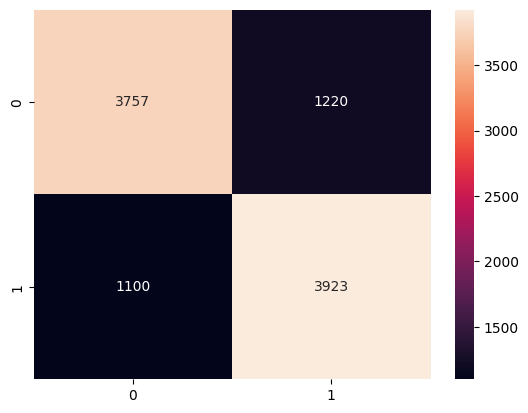

In [23]:
#confusion matrix and visual form
y_pred_prob = model.predict(X_test_pad)
y_pred = np.where(y_pred_prob > 0.5, 1, 0)

cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [24]:
#Model's Sentiment Prediction Counts

In [25]:
# Convert your sigmoid probabilities (0.0 to 1.0) into hard 0 or 1 classifications
binary_predictions = (y_pred > 0.5).astype(int)

# Flatten the array and count the values
prediction_counts = pd.Series(binary_predictions.flatten()).value_counts()

print("--- Model's Sentiment Prediction Counts ---")
print(f"Negative Texts Detected (0): {prediction_counts.get(0, 0)}")
print(f"Positive Texts Detected (1): {prediction_counts.get(1, 0)}")

--- Model's Sentiment Prediction Counts ---
Negative Texts Detected (0): 4857
Positive Texts Detected (1): 5143


In [26]:
#TEST ONE USER INPUT TEXT

In [27]:
# 1. First, make sure y_pred is defined for your evaluation cells
# This calculates predictions on your test pad data
y_pred = model.predict(X_test_pad)

# 2. Define a quick function to test any custom sentence you want
def test_my_own_text(text):
    # Clean the raw text using your notebook's clean_text function
    cleaned = clean_text(text)

    # Convert text to sequence of numbers using your fitted tokenizer
    seq = tokenizer.texts_to_sequences([cleaned])

    # Pad it to length 100 so the Bi-LSTM can read it
    padded = pad_sequences(seq, maxlen=100)

    # Get prediction score (0.0 to 1.0)
    score = model.predict(padded)[0][0]

    # Determine label based on 0.5 threshold
    sentiment = "POSITIVE" if score > 0.5 else "NEGATIVE"
    confidence = score if sentiment == "POSITIVE" else (1 - score)

    print(f"\nText: '{text}'")
    print(f"Result: {sentiment} ({confidence * 100:.2f}% confident)")

# 3. TEST IT LIVE HERE: Change these sentences to whatever you want!
test_my_own_text("This deep learning model is working perfectly, I love it!")
test_my_own_text("I am so frustrated because my code keeps throwing errors.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Text: 'This deep learning model is working perfectly, I love it!'
Result: POSITIVE (99.48% confident)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Text: 'I am so frustrated because my code keeps throwing errors.'
Result: NEGATIVE (83.04% confident)


In [29]:
#TEST UI
#here connect with database for store data
# 1. Create the UI Elements

text_input = widgets.Text(
    value='',
    placeholder='Type your tweet or sentence here to save it...',
    description='Text:',
    layout=widgets.Layout(width='60%')
)

submit_button = widgets.Button(
    description='Analyze & Save',
    button_style='success',
    tooltip='Predict sentiment and append to dataset',
    icon='save'
)

output_area = widgets.Output()

# 2. Define the button behavior
def on_button_clicked(b):
    with output_area:
        clear_output()

        user_text = text_input.value.strip()
        if not user_text:
            print("❌ Please enter some text first!")
            return

        # Run your notebook's preprocessing pipeline
        cleaned = clean_text(user_text)
        seq = tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=100)

        # Predict using your trained model
        score = model.predict(padded, verbose=0)[0][0]

        # Determine target sentiment integer (0 for negative, 1 for positive)
        predicted_sentiment_int = 1 if score > 0.5 else 0
        sentiment_label = "🎉 POSITIVE" if predicted_sentiment_int == 1 else "😡 NEGATIVE"
        color = "\033[92m" if predicted_sentiment_int == 1 else "\033[91m"
        confidence = score if predicted_sentiment_int == 1 else (1 - score)

        # --- SAVE TO A WRITABLE CSV FILE ---
        # Instead of the read-only Kaggle folder, save to Colab's local /content/ directory
        csv_file_path = "/content/my_updated_sentiment_data.csv"

        try:
            # Check if file exists to write headers if it's brand new
            file_exists = os.path.isfile(csv_file_path)

            new_row = [predicted_sentiment_int, 999999, "Today", "NO_QUERY", "Colab_UI", user_text]

            with open(csv_file_path, mode='a', newline='', encoding='utf-8') as file:
                writer = csv.writer(file)
                if not file_exists:
                    # Optional: Add headers if the file is being created for the first time
                    writer.writerow(["sentiment", "id", "date", "query", "user", "text"])
                writer.writerow(new_row)

            print(f"💾 Successfully saved locally to: {csv_file_path}")
        except Exception as e:
            print(f"⚠️ Could not write to file: {e}")

        # Output results to UI
        print(f"Analyzing: '{user_text}'")
        print(f"Result: {color}{sentiment_label}\033[0m ({confidence * 100:.2f}%)")

# 3. Connect and Display
submit_button.on_click(on_button_clicked)

print("--- Interactive Sentiment Analyzer & Data Saver ---")
display(widgets.HBox([text_input, submit_button]))
display(output_area)

--- Interactive Sentiment Analyzer & Data Saver ---


Output()

In [ ]:
# 1. Point to the local file where your widget saves data
local_file_path = "/content/my_updated_sentiment_data.csv"

# 2. Read your custom file
# Note: Since we added a header row in the fix, we don't need header=None anymore
updated_df = pd.read_csv(local_file_path, encoding="utf-8")

print(f"Total custom rows saved so far: {len(updated_df)}")
print("\nLast row in your saved file:")
print(updated_df.tail(1).values)

In [ ]:
updated_df.info()

In [ ]:
#TEST MODEL  Bidirectional_GRU , Bidirectional_LSTM-GRU

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense

gru_model = Sequential()

gru_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

gru_model.add(
    Bidirectional(
        GRU(64)
    )
)

gru_model.add(
    Dense(1, activation="sigmoid")
)

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

In [ ]:
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
loss, accuracy = gru_model.evaluate(
    X_test_pad,
    y_test
)

print("Accuracy:", accuracy)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense

bi_model = Sequential()

bi_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

bi_model.add(
    Bidirectional(
        LSTM(64, return_sequences=True)
    )
)

bi_model.add(
    GRU(32)
)

bi_model.add(
    Dense(1, activation="sigmoid")
)

bi_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bi_model.summary()

In [ ]:
#train the Model
history_bi = bi_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
#evaluate on test data
loss_lstm, accuracy_lstm =bi_model.evaluate(
    X_test_pad,
    y_test
)

print(f"Bi-LSTM Accuracy: {accuracy_lstm*100:.2f}%")

In [ ]:
#classifacation report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

In [ ]:

# # ---

# # ### 1. The Core System & Data Downloaders

# # * **`import os`**
# # Handles file paths and directory management (e.g., checking what files are in your Colab workspace using `os.listdir()`).
# # * **`import kagglehub`**
# # The official tool used to programmatically download your `sentiment140` dataset directly from Kaggle into your Colab environment.
# # * **`import re`**
# # The Regular Expressions (Regex) library. You use this in your `clean_text` function to strip out URLs, `@mentions`, and hashtags from raw tweets.
# # * **`import csv`**
# # Allows your interactive UI widget to write, append, and log your custom text inputs into a local CSV file.

# # ---

# # ### 2. Data Science & Visualization Essentials

# # * **`import seaborn as sns`**
# # A data visualization library built on top of matplotlib. You use it here to draw the clean, colored heatmap for your confusion matrix.
# # * **`import matplotlib.pyplot as plt`**
# # The fundamental plotting engine. It actually handles rendering, sizing, and showing the graphs/plots on your screen.
# # * **`import numpy as np`**
# # Handles heavy mathematical arrays. It helps process your model's raw probability outputs and convert them into binary `0` or `1` predictions.
# # * **`import pandas as pd`**
# # The ultimate data structuring tool. It loads your massive CSV file into a clean table (DataFrame), cleans your columns, and samples your data.

# # ---

# # ### 3. Machine Learning Utilities (Scikit-Learn)

# # * **`from sklearn.model_selection import train_test_split`**
# # Splits your dataset into training data (80% to teach your model) and testing data (20% to grade your model).
# # * **`from sklearn.metrics import confusion_matrix`**
# # Generates the matrix that counts exactly how many times your model guessed right vs. how many times it missed (True Positives, False Negatives, etc.).

# ┌──────────────────────────────────────────┐
#                   │          Input Sequence (1x100)          │
#                   └────────────────────┬─────────────────────┘
#                                        ▼
#                   ┌──────────────────────────────────────────┐
#                   │             Embedding Layer              │  <-- Turns word IDs into rich
#                   │         (128-dimensional vectors)        │      geometric coordinates
#                   └────────────────────┬─────────────────────┘
#                                        ▼
#                   ┌──────────────────────────────────────────┐
#                   │      Bidirectional Layer (LSTM/GRU)      │  <-- Reads text left-to-right
#                   │       (Processes past & future)          │      AND right-to-left
#                   └────────────────────┬─────────────────────┘
#                                        ▼
#                   ┌──────────────────────────────────────────┐
#                   │              Dropout Layer               │  <-- Drops neurons randomly
#                   │         (Prevents Overfitting)           │      to stabilize validation
#                   └────────────────────┬─────────────────────┘
#                                        ▼
#                   ┌──────────────────────────────────────────┐
#                   │           Dense Output Layer             │  <-- Condenses patterns to a
#                   │           (Sigmoid Activation)           │      single decimal probability
#                   └──────────────────────────────────────────┘
# # ---

# # ### 4. Natural Language Preprocessing (Keras)

# # * **`from tensorflow.keras.preprocessing.sequence import pad_sequences`**
# # Sentences have different lengths. This ensures every single text sequence gets padded with zeros to be exactly 100 tokens long so the neural network can ingest it uniformly.

# # ---

# # ### 5. Building the Deep Learning Architecture (Keras Layers)

# # * **`from tensorflow.keras.models import Sequential`**
# # The backbone model container. It allows you to stack layers sequentially from input to output, like building blocks.
# # * **`from tensorflow.keras.layers import Embedding`**
# # The very first layer. It converts text numbers into dense vector spaces, turning words into meaningful geometric coordinates where similar words sit close together.
# # * **`from tensorflow.keras.layers import Bidirectional`**
# # The wrapper that duplicates your recurrent layers so they can read text from left-to-right **and** right-to-left at the same time.
# # * **`from tensorflow.keras.layers import LSTM , GRU`**
# # The recurrent neural network engines. They remember long-term patterns and context inside your text data.
# # * **`from tensorflow.keras.layers import Dense`**
# # The final output layer. It takes all the patterns found by your LSTMs/GRUs and condenses them down to a single `sigmoid` probability score between `0` (Negative) and `1` (Positive).

# # ---

# # ### 6. Interactive User Interface Components

# # * **`import ipywidgets as widgets`**
# # Provides the physical text box and the green "Analyze & Save" button inside your notebook.
# # * **`from IPython.display import display, clear_output`**
# # Handles the live updates in your UI—clearing out the old analysis result when you click the button and displaying the brand-new sentiment result instantly.


# # 7 Fix the Overfitting (High Priority)
# # Looking at your training logs for the Bi-LSTM:

# # Epoch 2: Training Accuracy = 81.04% | Validation Accuracy = 77.38%

# # Epoch 3: Training Accuracy = 84.17% | Validation Accuracy = 76.53%

# # Notice how your training accuracy keeps going up, but your validation accuracy starts dropping? Your model is beginning to overfit (memorizing the training data instead of learning patterns).

# # The Fix: Add a Dropout layer right after your Bidirectional layer to force the model to generalize better.